# DATA PREPARATION and EXPLORATION

**For my project I need 3 dataset**


*   Sleep Data (Sleep Data from Apple Health)
*   Calorie Data (Calorie Data from my Apple Watch)
*   Activity Data (Step Count from Apple Health)




In [ ]:
import pandas as pd
import re
import os
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import xml.etree.ElementTree as ET


## Calorie Data from my Apple Watch

In [ ]:
def parse_energy_data(file_path, record_type):
    # Read file content
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    # Regex pattern to extract records
    pattern = fr'<Record type="{record_type}".*?startDate="(.*?)".*?endDate="(.*?)".*?value="(.*?)"'
    matches = re.findall(pattern, content)

    # Parse into list of records
    records = []
    for start, end, value in matches:
        try:
            start_dt = datetime.strptime(start, '%Y-%m-%d %H:%M:%S %z')
            end_dt = datetime.strptime(end, '%Y-%m-%d %H:%M:%S %z')
            kcal = float(value)
            day = end_dt.date().isoformat()  # Use the end of the interval

            records.append({
                'date': day,
                'start_time': start_dt,
                'end_time': end_dt,
                'kcal': kcal
            })
        except Exception as e:
            print(f"Error parsing record: {e}")

    df = pd.DataFrame(records)

    if df.empty:
        print("No records parsed.")
        return df

    # Summarize per day
    df_summary = df.groupby('date')['kcal'].sum().reset_index()
    df_summary['kcal'] = df_summary['kcal'].round(2)
    df_summary['date'] = pd.to_datetime(df_summary['date'])
    df_summary = df_summary.sort_values('date')

    return df_summary


In [ ]:
active_df = parse_energy_data('/content/HKQuantityTypeIdentifierActiveEnergyBurned.txt',
                              'HKQuantityTypeIdentifierActiveEnergyBurned')

basal_df = parse_energy_data('/content/HKQuantityTypeIdentifierBasalEnergyBurned.txt',
                             'HKQuantityTypeIdentifierBasalEnergyBurned')


In [ ]:
# Merge on date
total_energy_df = pd.merge(basal_df, active_df, on='date', how='outer', suffixes=('_basal', '_active')).fillna(0)
total_energy_df['total_kcal'] = total_energy_df['kcal_basal'] + total_energy_df['kcal_active']
total_energy_df = total_energy_df.sort_values('date')

# Preview
total_energy_df.head()


,date,kcal_basal,kcal_active,total_kcal
0,2024-09-08,610.56,0.00,610.56
1,2024-09-09,2175.09,238.04,2413.13
2,2024-09-10,2067.93,168.47,2236.40
3,2024-09-16,2151.58,11.52,2163.10
4,2024-09-17,2454.68,837.12,3291.80


In [ ]:
total_energy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         126 non-null    datetime64[ns]
 1   kcal_basal   126 non-null    float64       
 2   kcal_active  126 non-null    float64       
 3   total_kcal   126 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 4.1 KB


**The current dataset with 126 entries is too small for robust statistical analysis and hypothesis testing so i will use sleep and step count data from apple health**

## Sleep Data from Apple Health

In [ ]:
# Parse the XML file
print("Extracting sleep data from Apple Health export.xml...")
file_path = "export.xml"
tree = ET.parse(file_path)
root = tree.getroot()

# Extract sleep records
sleep_data = []
for record in root.findall(".//Record"):
    if record.attrib.get('type') == 'HKCategoryTypeIdentifierSleepAnalysis':
        start_date = record.attrib.get('startDate')
        end_date = record.attrib.get('endDate')
        value = record.attrib.get('value')

        if start_date and end_date:
            # Convert start date string to datetime for filtering
            start_dt = pd.to_datetime(start_date)

            # Filter for records from 2022 onwards
            if start_dt.year >= 2022:
                sleep_data.append({
                    'Start Date': start_date,
                    'End Date': end_date,
                    'Sleep Value': value
                })

print(f"Found {len(sleep_data)} sleep records from 2022 onwards")

Extracting sleep data from Apple Health export.xml...
Found 3112 sleep records from 2022 onwards


In [ ]:
# Create DataFrame
df = pd.DataFrame(sleep_data)

# Convert date columns to datetime
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])

# Add metadata columns
df['Date'] = df['Start Date'].dt.date
df['Year'] = df['Start Date'].dt.year
df['Month'] = df['Start Date'].dt.month
df['Month Name'] = df['Start Date'].dt.month_name()
df['Day of Week'] = df['Start Date'].dt.day_name()

# Calculate sleep duration in hours
df['Sleep Duration (hours)'] = (df['End Date'] - df['Start Date']).dt.total_seconds() / 3600

# Filter out unreasonable sleep durations
original_count = len(df)
df = df[(df['Sleep Duration (hours)'] <= 24) & (df['Sleep Duration (hours)'] >= 0.25)]
print(f"Removed {original_count - len(df)} records with unreasonable durations")

# Create daily summary - this is our main dataframe for analysis
daily_sleep = df.groupby('Date').agg({
    'Sleep Duration (hours)': 'sum',
    'Start Date': ['min', 'max', 'count']
}).reset_index()

# Flatten column hierarchy
daily_sleep.columns = ['Date', 'Total Sleep Hours', 'First Sleep Start', 'Last Sleep End', 'Number of Sessions']

# Add metadata columns
daily_sleep['Date'] = pd.to_datetime(daily_sleep['Date'])
daily_sleep['Year'] = daily_sleep['Date'].dt.year
daily_sleep['Month'] = daily_sleep['Date'].dt.month
daily_sleep['Month Name'] = daily_sleep['Date'].dt.month_name()
daily_sleep['Day of Week'] = daily_sleep['Date'].dt.day_name()
daily_sleep['Day of Month'] = daily_sleep['Date'].dt.day
daily_sleep['Week of Year'] = daily_sleep['Date'].dt.isocalendar().week

# Add bedtime and wake time
daily_sleep['Bedtime'] = daily_sleep['First Sleep Start'].dt.strftime('%H:%M')
daily_sleep['Wake Time'] = daily_sleep['Last Sleep End'].dt.strftime('%H:%M')
daily_sleep['Sleep Duration (minutes)'] = daily_sleep['Total Sleep Hours'] * 60

# Save to CSV file
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_filename = f"daily_sleep_2022o2022-NOW.csv"
daily_sleep.to_csv(csv_filename, index=False)
print(f"Saved daily sleep duration data to {csv_filename}")

Removed 2076 records with unreasonable durations
Saved daily sleep duration data to daily_sleep_2022o2022-NOW.csv


In [ ]:
print("DATA EXPLORATION")
print("-------------------------")

# Calculate basic statistics
avg_sleep = daily_sleep['Total Sleep Hours'].mean()
med_sleep = daily_sleep['Total Sleep Hours'].median()
min_sleep = daily_sleep['Total Sleep Hours'].min()
max_sleep = daily_sleep['Total Sleep Hours'].max()
std_sleep = daily_sleep['Total Sleep Hours'].std()

# Percentage of days with adequate sleep (7+ hours)
adequate_sleep_pct = (daily_sleep['Total Sleep Hours'] >= 7).mean() * 100

# Print summary statistics
print(f"Data Summary (2022 onwards):")
print(f"Date range: {daily_sleep['Date'].min().date()} to {daily_sleep['Date'].max().date()}")
print(f"Total days recorded: {len(daily_sleep)}")
print(f"Average daily sleep: {avg_sleep:.2f} hours")
print(f"Median daily sleep: {med_sleep:.2f} hours")
print(f"Sleep duration range: {min_sleep:.2f} to {max_sleep:.2f} hours")
print(f"Standard deviation: {std_sleep:.2f} hours")
print(f"Days with adequate sleep (7+ hours): {adequate_sleep_pct:.1f}%")

# Analysis by day of week
dow_stats = daily_sleep.groupby('Day of Week')['Total Sleep Hours'].agg(['mean', 'median', 'count']).reset_index()
# Reorder days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_stats = dow_stats.set_index('Day of Week').reindex(day_order).reset_index()

print("\nSleep by Day of Week:")
for _, row in dow_stats.iterrows():
    print(f"{row['Day of Week']}: {row['mean']:.2f} hours (n={row['count']})")

# Weekday vs Weekend comparison
weekday_sleep = daily_sleep[daily_sleep['Day of Week'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])]['Total Sleep Hours'].mean()
weekend_sleep = daily_sleep[daily_sleep['Day of Week'].isin(['Saturday', 'Sunday'])]['Total Sleep Hours'].mean()
print(f"\nWeekday average: {weekday_sleep:.2f} hours")
print(f"Weekend average: {weekend_sleep:.2f} hours")
print(f"Difference: {abs(weekend_sleep - weekday_sleep):.2f} hours")

# Monthly trends
monthly_stats = daily_sleep.groupby(['Year', 'Month'])['Total Sleep Hours'].agg(['mean', 'median', 'count']).reset_index()
monthly_stats['YearMonth'] = monthly_stats['Year'].astype(str) + '-' + monthly_stats['Month'].astype(str).str.zfill(2)

print("\nMonthly Sleep Trends:")
for _, row in monthly_stats.iterrows():
    print(f"{row['YearMonth']}: {row['mean']:.2f} hours (n={row['count']} days)")

# Check for correlation between bedtime and sleep duration
daily_sleep['Bedtime Hour'] = daily_sleep['First Sleep Start'].dt.hour + daily_sleep['First Sleep Start'].dt.minute/60
correlation = daily_sleep['Bedtime Hour'].corr(daily_sleep['Total Sleep Hours'])
print(f"\nCorrelation between bedtime and sleep duration: {correlation:.3f}")



DATA EXPLORATION
-------------------------
Data Summary (2022 onwards):
Date range: 2022-01-03 to 2024-09-17
Total days recorded: 703
Average daily sleep: 5.85 hours
Median daily sleep: 6.00 hours
Sleep duration range: 0.57 to 7.08 hours
Standard deviation: 1.13 hours
Days with adequate sleep (7+ hours): 15.2%

Sleep by Day of Week:
Monday: 6.05 hours (n=142.0)
Tuesday: 5.91 hours (n=142.0)
Wednesday: 5.77 hours (n=140.0)
Thursday: 5.82 hours (n=141.0)
Friday: 5.72 hours (n=138.0)
Saturday: nan hours (n=nan)
Sunday: nan hours (n=nan)

Weekday average: 5.85 hours
Weekend average: nan hours
Difference: nan hours

Monthly Sleep Trends:
2022-01: 5.14 hours (n=21 days)
2022-02: 5.59 hours (n=20 days)
2022-03: 5.64 hours (n=22 days)
2022-04: 5.15 hours (n=21 days)
2022-05: 5.15 hours (n=22 days)
2022-06: 5.39 hours (n=22 days)
2022-07: 5.60 hours (n=21 days)
2022-08: 5.57 hours (n=23 days)
2022-09: 5.28 hours (n=21 days)
2022-10: 5.92 hours (n=21 days)
2022-11: 6.11 hours (n=21 days)
2022-12

In [ ]:
daily_sleep.head()

,Date,Total Sleep Hours,First Sleep Start,Last Sleep End,Number of Sessions,Year,Month,Month Name,Day of Week,Day of Month,Week of Year,Bedtime,Wake Time,Sleep Duration (minutes),Bedtime Hour
0,2022-01-03,3.909167,2022-01-03 04:05:28+03:00,2022-01-03 04:05:28+03:00,1,2022,1,January,Monday,3,1,04:05,04:05,234.550000,4.083333
1,2022-01-04,6.000000,2022-01-04 02:00:00+03:00,2022-01-04 02:00:00+03:00,1,2022,1,January,Tuesday,4,1,02:00,02:00,360.000000,2.000000
2,2022-01-05,6.000278,2022-01-05 02:00:00+03:00,2022-01-05 02:00:00+03:00,1,2022,1,January,Wednesday,5,1,02:00,02:00,360.016667,2.000000
3,2022-01-06,5.463056,2022-01-06 02:32:14+03:00,2022-01-06 02:32:14+03:00,1,2022,1,January,Thursday,6,1,02:32,02:32,327.783333,2.533333
4,2022-01-07,6.000278,2022-01-07 02:00:00+03:00,2022-01-07 02:00:00+03:00,1,2022,1,January,Friday,7,1,02:00,02:00,360.016667,2.000000


In [ ]:
daily_sleep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 703 entries, 0 to 702
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype                    
---  ------                    --------------  -----                    
 0   Date                      703 non-null    datetime64[ns]           
 1   Total Sleep Hours         703 non-null    float64                  
 2   First Sleep Start         703 non-null    datetime64[ns, UTC+03:00]
 3   Last Sleep End            703 non-null    datetime64[ns, UTC+03:00]
 4   Number of Sessions        703 non-null    int64                    
 5   Year                      703 non-null    int32                    
 6   Month                     703 non-null    int32                    
 7   Month Name                703 non-null    object                   
 8   Day of Week               703 non-null    object                   
 9   Day of Month              703 non-null    int32                    
 10  Week of Year  

## Step Count from Apple Health

In [ ]:
print("DATA PREPARATION")
print("------------------------")

# Parse the XML file
print("Extracting step count data from Apple Health export.xml...")
file_path = "export.xml"
tree = ET.parse(file_path)
root = tree.getroot()

# Extract step count records
step_data = []
for record in root.findall(".//Record"):
    if record.attrib.get('type') == 'HKQuantityTypeIdentifierStepCount':
        date = record.attrib.get('startDate')
        count = record.attrib.get('value')
        source = record.attrib.get('sourceName', 'Unknown')

        if date and count:
            # Convert date string to datetime for filtering
            date_dt = pd.to_datetime(date)

            # Filter for records from 2022 onwards
            if date_dt.year >= 2022:
                step_data.append({
                    'Date': date,
                    'Step Count': int(float(count)),
                    'Source': source
                })

print(f"Found {len(step_data)} step count records from 2022 onwards")

DATA PREPARATION
------------------------
Extracting step count data from Apple Health export.xml...
Found 48567 step count records from 2022 onwards


In [ ]:
# Create DataFrame
df = pd.DataFrame(step_data)

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Add metadata columns
df['Day'] = df['Date'].dt.date
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month Name'] = df['Date'].dt.month_name()
df['Day of Week'] = df['Date'].dt.day_name()
df['Hour'] = df['Date'].dt.hour

# Filter out unreasonable step counts (e.g., over 100,000 steps in a single record)
original_count = len(df)
df = df[df['Step Count'] <= 100000]
print(f"Removed {original_count - len(df)} records with unreasonable step counts")

# Create daily summary - this is our main dataframe for analysis
daily_steps = df.groupby('Day').agg({
    'Step Count': 'sum',
    'Date': ['min', 'max', 'count']
}).reset_index()

# Flatten column hierarchy
daily_steps.columns = ['Day', 'Total Steps', 'First Record Time', 'Last Record Time', 'Number of Records']

# Add metadata columns
daily_steps['Day'] = pd.to_datetime(daily_steps['Day'])  # Ensure Day is datetime

# Calculate active periods
hourly_steps = df.groupby(['Day', 'Hour'])['Step Count'].sum().reset_index()
hourly_steps['Active'] = hourly_steps['Step Count'] > 100  # Define active as hours with >100 steps

# Convert Day to datetime in hourly_steps to match daily_steps
hourly_steps['Day'] = pd.to_datetime(hourly_steps['Day'])

active_hours = hourly_steps.groupby('Day')['Active'].sum().reset_index()
daily_steps = pd.merge(daily_steps, active_hours, on='Day', how='left')
daily_steps.rename(columns={'Active': 'Active Hours'}, inplace=True)

# Now continue with the rest of the metadata columns
daily_steps['Year'] = daily_steps['Day'].dt.year
daily_steps['Month'] = daily_steps['Day'].dt.month
daily_steps['Month Name'] = daily_steps['Day'].dt.month_name()
daily_steps['Day of Week'] = daily_steps['Day'].dt.day_name()
daily_steps['Day of Month'] = daily_steps['Day'].dt.day
daily_steps['Week of Year'] = daily_steps['Day'].dt.isocalendar().week


# Calculate weekly averages
daily_steps['Week Start'] = daily_steps['Day'] - pd.to_timedelta(daily_steps['Day'].dt.dayofweek, unit='d')
weekly_avg = daily_steps.groupby('Week Start')['Total Steps'].mean().reset_index()
weekly_avg.columns = ['Week Start', 'Weekly Avg Steps']

# Merge weekly averages back to daily data
daily_steps = pd.merge(daily_steps, weekly_avg, on='Week Start', how='left')

# Save to CSV file
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_filename = f"daily_steps_2022-NOW.csv"
daily_steps.to_csv(csv_filename, index=False)
print(f"Saved daily step count data to {csv_filename}")

# Try to provide download link if in Colab
try:
    from google.colab import files
    files.download(csv_filename)
    print(f"Download link for {csv_filename} is available in Colab.")
except ImportError:
    print(f"CSV file saved to your working directory: {csv_filename}")

Removed 0 records with unreasonable step counts
Saved daily step count data to daily_steps_2022-NOW.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download link for daily_steps_2022-NOW.csv is available in Colab.


In [ ]:
print("EXPLORATION")
print("-------------------------")

# Calculate basic statistics
avg_steps = daily_steps['Total Steps'].mean()
med_steps = daily_steps['Total Steps'].median()
min_steps = daily_steps['Total Steps'].min()
max_steps = daily_steps['Total Steps'].max()
std_steps = daily_steps['Total Steps'].std()

# Percentage of days meeting recommended step count (10,000 steps)
recommended_pct = (daily_steps['Total Steps'] >= 10000).mean() * 100

# Print summary statistics
print(f"Data Summary (2022 onwards):")
print(f"Date range: {daily_steps['Day'].min().date()} to {daily_steps['Day'].max().date()}")
print(f"Total days recorded: {len(daily_steps)}")
print(f"Average daily steps: {avg_steps:.0f} steps")
print(f"Median daily steps: {med_steps:.0f} steps")
print(f"Step count range: {min_steps:.0f} to {max_steps:.0f} steps")
print(f"Standard deviation: {std_steps:.0f} steps")
print(f"Days meeting recommended steps (10,000+): {recommended_pct:.1f}%")

# Analysis by day of week
dow_stats = daily_steps.groupby('Day of Week')['Total Steps'].agg(['mean', 'median', 'count']).reset_index()
# Reorder days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_stats = dow_stats.set_index('Day of Week').reindex(day_order).reset_index()

print("\nSteps by Day of Week:")
for _, row in dow_stats.iterrows():
    print(f"{row['Day of Week']}: {row['mean']:.0f} steps (n={row['count']})")

# Weekday vs Weekend comparison
weekday_steps = daily_steps[daily_steps['Day of Week'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])]['Total Steps'].mean()
weekend_steps = daily_steps[daily_steps['Day of Week'].isin(['Saturday', 'Sunday'])]['Total Steps'].mean()
print(f"\nWeekday average: {weekday_steps:.0f} steps")
print(f"Weekend average: {weekend_steps:.0f} steps")
print(f"Difference: {abs(weekend_steps - weekday_steps):.0f} steps")

# Monthly trends
monthly_stats = daily_steps.groupby(['Year', 'Month'])['Total Steps'].agg(['mean', 'median', 'count']).reset_index()
monthly_stats['YearMonth'] = monthly_stats['Year'].astype(str) + '-' + monthly_stats['Month'].astype(str).str.zfill(2)

print("\nMonthly Step Trends:")
for _, row in monthly_stats.iterrows():
    print(f"{row['YearMonth']}: {row['mean']:.0f} steps (n={row['count']} days)")

# Active periods analysis
print(f"\nAverage active hours per day: {daily_steps['Active Hours'].mean():.1f}")

# Check for correlation between active hours and total steps
correlation = daily_steps['Active Hours'].corr(daily_steps['Total Steps'])
print(f"Correlation between active hours and total steps: {correlation:.3f}")


EXPLORATION
-------------------------
Data Summary (2022 onwards):
Date range: 2022-01-01 to 2025-05-20
Total days recorded: 1230
Average daily steps: 8713 steps
Median daily steps: 8110 steps
Step count range: 36 to 37174 steps
Standard deviation: 4100 steps
Days meeting recommended steps (10,000+): 28.8%

Steps by Day of Week:
Monday: 8720 steps (n=176)
Tuesday: 8730 steps (n=176)
Wednesday: 8539 steps (n=176)
Thursday: 8889 steps (n=175)
Friday: 9225 steps (n=175)
Saturday: 8953 steps (n=176)
Sunday: 7937 steps (n=176)

Weekday average: 8820 steps
Weekend average: 8445 steps
Difference: 375 steps

Monthly Step Trends:
2022-01: 9873 steps (n=31 days)
2022-02: 12178 steps (n=22 days)
2022-03: 8371 steps (n=31 days)
2022-04: 10082 steps (n=30 days)
2022-05: 9034 steps (n=31 days)
2022-06: 10479 steps (n=30 days)
2022-07: 9136 steps (n=31 days)
2022-08: 8810 steps (n=31 days)
2022-09: 12653 steps (n=30 days)
2022-10: 10645 steps (n=31 days)
2022-11: 10481 steps (n=30 days)
2022-12: 1196

In [ ]:
daily_steps.head()

,Day,Total Steps,First Record Time,Last Record Time,Number of Records,Active Hours,Year,Month,Month Name,Day of Week,Day of Month,Week of Year,Week Start,Weekly Avg Steps
0,2022-01-01,7217,2022-01-01 00:17:13+03:00,2022-01-01 21:02:08+03:00,31,5,2022,1,January,Saturday,1,52,2021-12-27,7717.000000
1,2022-01-02,8217,2022-01-02 11:25:06+03:00,2022-01-02 22:27:25+03:00,22,7,2022,1,January,Sunday,2,52,2021-12-27,7717.000000
2,2022-01-03,4446,2022-01-03 08:48:49+03:00,2022-01-03 22:42:07+03:00,17,4,2022,1,January,Monday,3,1,2022-01-03,7779.142857
3,2022-01-04,14075,2022-01-04 08:47:01+03:00,2022-01-04 23:56:21+03:00,42,14,2022,1,January,Tuesday,4,1,2022-01-03,7779.142857
4,2022-01-05,9600,2022-01-05 00:50:16+03:00,2022-01-05 22:46:48+03:00,29,5,2022,1,January,Wednesday,5,1,2022-01-03,7779.142857


In [ ]:
daily_steps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1230 entries, 0 to 1229
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype                    
---  ------             --------------  -----                    
 0   Day                1230 non-null   datetime64[ns]           
 1   Total Steps        1230 non-null   int64                    
 2   First Record Time  1230 non-null   datetime64[ns, UTC+03:00]
 3   Last Record Time   1230 non-null   datetime64[ns, UTC+03:00]
 4   Number of Records  1230 non-null   int64                    
 5   Active Hours       1230 non-null   int64                    
 6   Year               1230 non-null   int32                    
 7   Month              1230 non-null   int32                    
 8   Month Name         1230 non-null   object                   
 9   Day of Week        1230 non-null   object                   
 10  Day of Month       1230 non-null   int32                    
 11  Week of Year       1230 non-nu

# DATA VISUALİZATİON

Generating visualizations...


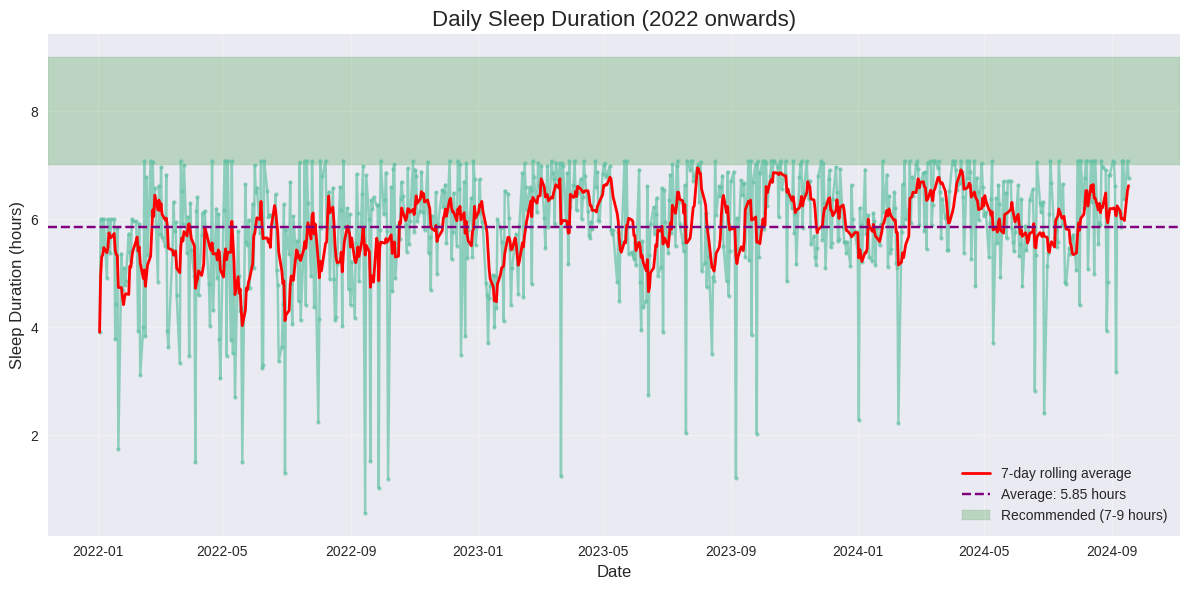

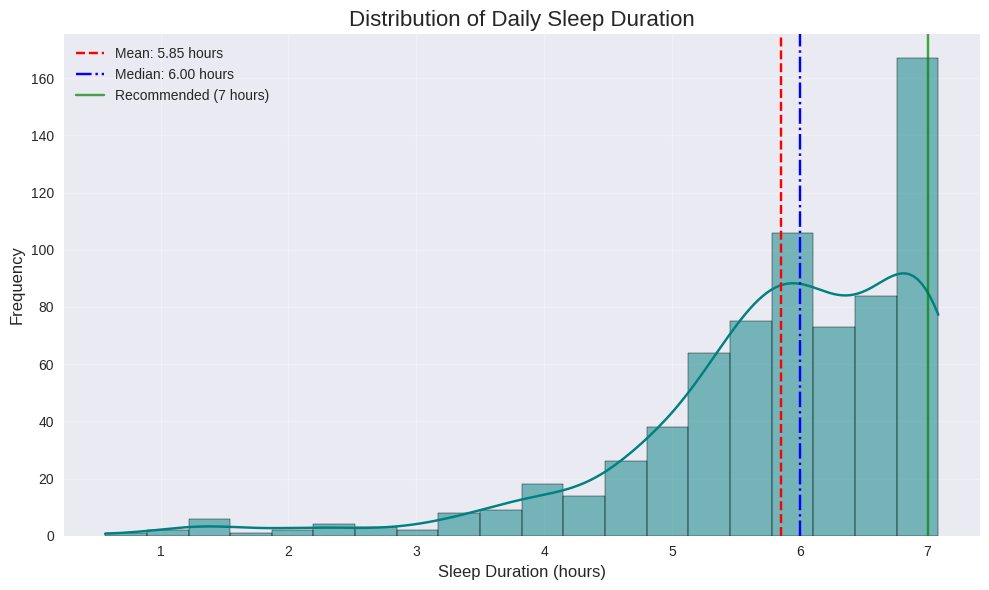

<ipython-input-38-5bd4c8a277a9>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Day of Week', y='Total Sleep Hours', data=daily_sleep, order=day_order,


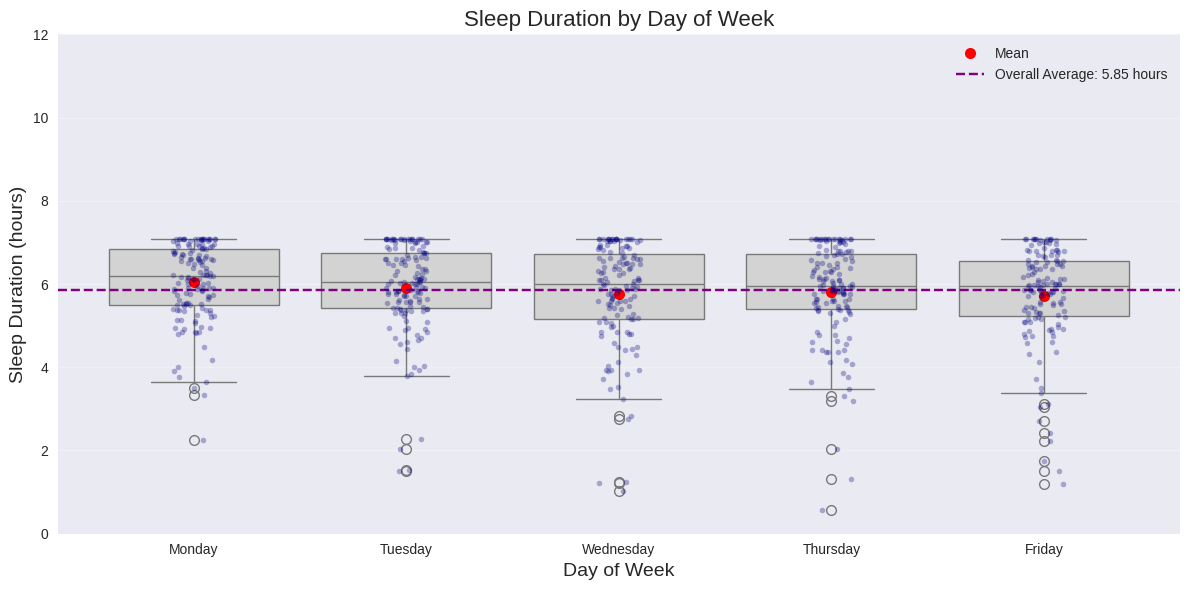

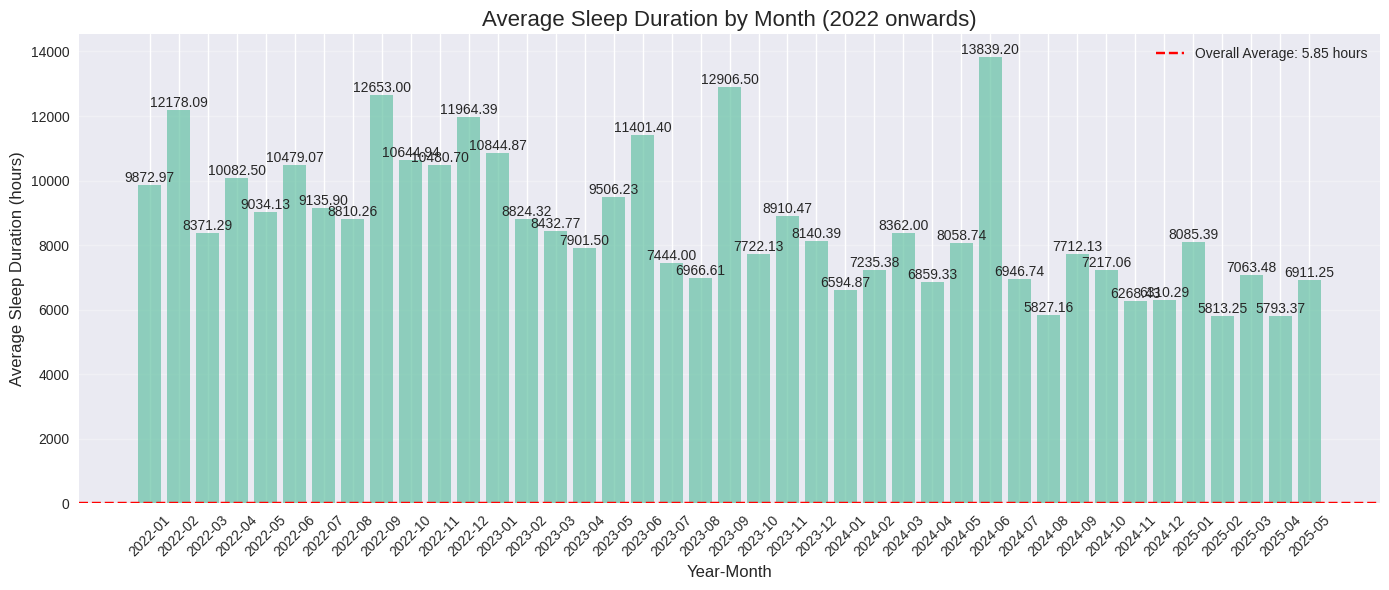

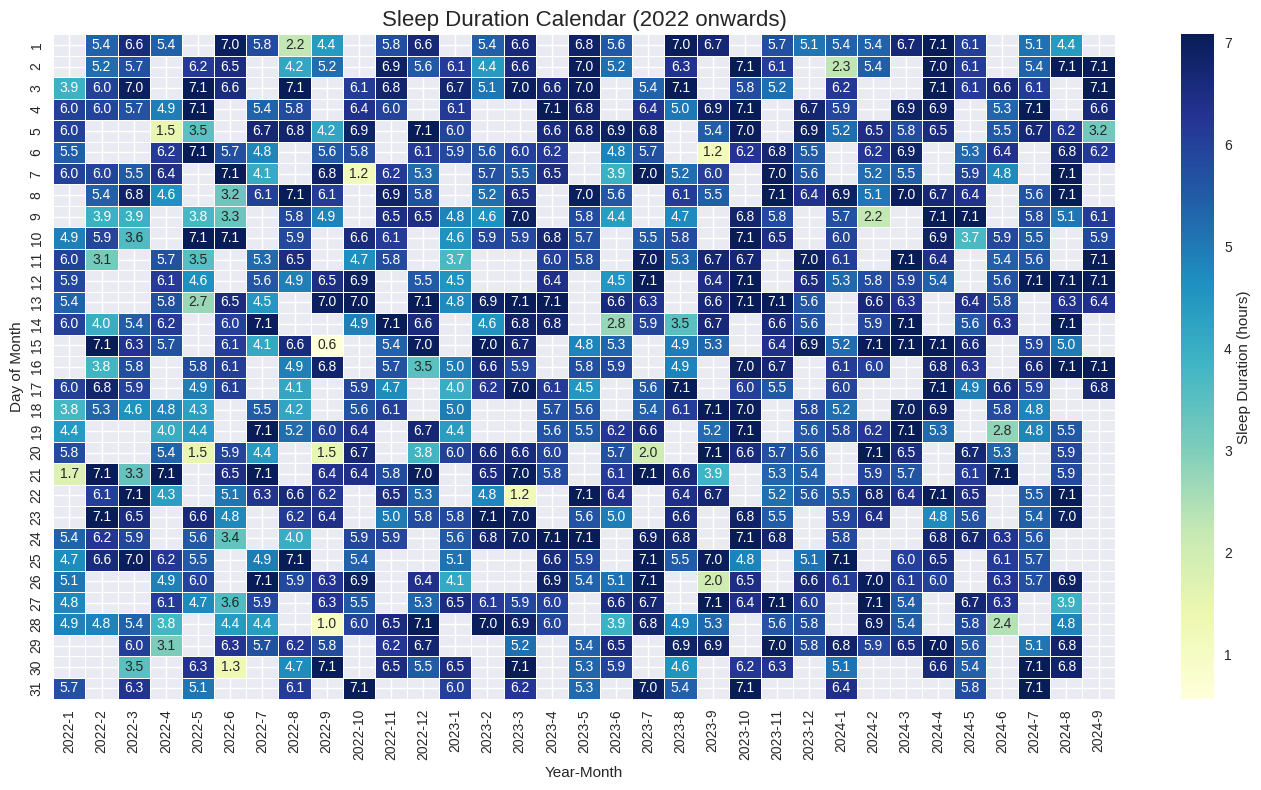

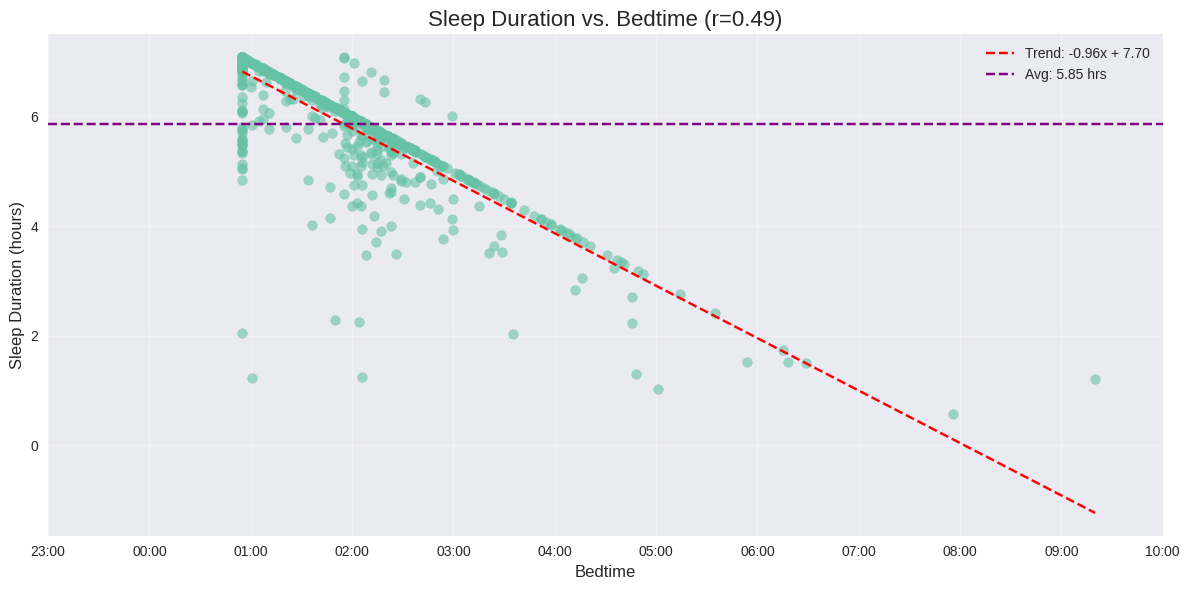


Analysis complete! The CSV file contains all daily sleep data from 2022 onwards.


In [ ]:
import numpy as np

print("Generating visualizations...")

# Set the visual style for all plots
plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")

# 1. Sleep duration timeline
plt.figure(figsize=(12, 6))
plt.plot(daily_sleep['Date'], daily_sleep['Total Sleep Hours'], '-o', markersize=3, alpha=0.7)

# Add rolling average
daily_sleep['7d_avg'] = daily_sleep['Total Sleep Hours'].rolling(window=7, min_periods=1).mean()
plt.plot(daily_sleep['Date'], daily_sleep['7d_avg'], 'r-', linewidth=2, label='7-day rolling average')

plt.axhline(y=avg_sleep, color='purple', linestyle='--', label=f'Average: {avg_sleep:.2f} hours')
plt.axhspan(7, 9, alpha=0.2, color='green', label='Recommended (7-9 hours)')
plt.title('Daily Sleep Duration (2022 onwards)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sleep Duration (hours)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Sleep duration histogram
plt.figure(figsize=(10, 6))
sns.histplot(daily_sleep['Total Sleep Hours'], bins=20, kde=True, color='teal')
plt.axvline(x=avg_sleep, color='red', linestyle='--', label=f'Mean: {avg_sleep:.2f} hours')
plt.axvline(x=med_sleep, color='blue', linestyle='-.', label=f'Median: {med_sleep:.2f} hours')
plt.axvline(x=7, color='green', linestyle='-', alpha=0.7, label='Recommended (7 hours)')
plt.title('Distribution of Daily Sleep Duration', fontsize=16)
plt.xlabel('Sleep Duration (hours)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Day of week comparison
plt.figure(figsize=(12, 6))

# Create compound visualization: boxplot with individual points
ax = sns.boxplot(x='Day of Week', y='Total Sleep Hours', data=daily_sleep, order=day_order,
                palette=['lightblue' if day in ['Saturday', 'Sunday'] else 'lightgrey' for day in day_order])
sns.stripplot(x='Day of Week', y='Total Sleep Hours', data=daily_sleep, order=day_order,
             size=4, alpha=0.3, jitter=True, color='navy')

# Add mean markers
for i, day in enumerate(day_order):
    mean_val = daily_sleep[daily_sleep['Day of Week'] == day]['Total Sleep Hours'].mean()
    plt.plot(i, mean_val, 'ro', markersize=8, label='Mean' if i == 0 else "")

plt.axhline(y=avg_sleep, color='purple', linestyle='--', label=f'Overall Average: {avg_sleep:.2f} hours')
plt.title('Sleep Duration by Day of Week', fontsize=16)
plt.xlabel('Day of Week', fontsize=14)
plt.ylabel('Sleep Duration (hours)', fontsize=14)
plt.ylim(0, max(12, daily_sleep['Total Sleep Hours'].max() + 1))
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 4. Monthly average sleep
plt.figure(figsize=(14, 6))
monthly_data = monthly_stats.sort_values('YearMonth')

bars = plt.bar(monthly_data['YearMonth'], monthly_data['mean'], alpha=0.7)

# Add data labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.2f}', ha='center', va='bottom')

plt.axhline(y=avg_sleep, color='red', linestyle='--', label=f'Overall Average: {avg_sleep:.2f} hours')
plt.title('Average Sleep Duration by Month (2022 onwards)', fontsize=16)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Average Sleep Duration (hours)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.tight_layout()
plt.show()

# 5. Sleep quality calendar heatmap
plt.figure(figsize=(14, 8))
# Prepare data for heatmap
cal_data = daily_sleep.copy()

# Create pivot table for the heatmap (day of month vs month, colored by sleep hours)
pivot_data = pd.pivot_table(
    cal_data,
    values='Total Sleep Hours',
    index='Day of Month',
    columns=['Year', 'Month'],
    aggfunc='mean'
)

# Plot heatmap
ax = sns.heatmap(pivot_data, cmap='YlGnBu', annot=True, fmt='.1f',
                linewidths=.5, cbar_kws={'label': 'Sleep Duration (hours)'})

plt.title('Sleep Duration Calendar (2022 onwards)', fontsize=16)
plt.tight_layout()
plt.show()

# 6. Scatter plot: Bedtime vs Sleep Duration
plt.figure(figsize=(12, 6))

# Adjust hours after midnight to negative values for better visualization
adjusted_hours = daily_sleep['Bedtime Hour'].copy()
adjusted_hours[adjusted_hours > 12] = adjusted_hours[adjusted_hours > 12] - 24

# Create scatter plot
plt.scatter(adjusted_hours, daily_sleep['Total Sleep Hours'], alpha=0.6)

# Add trend line
z = np.polyfit(adjusted_hours, daily_sleep['Total Sleep Hours'], 1)
p = np.poly1d(z)
x_trend = np.linspace(adjusted_hours.min(), adjusted_hours.max(), 100)
plt.plot(x_trend, p(x_trend), 'r--', label=f'Trend: {z[0]:.2f}x + {z[1]:.2f}')

# Create custom x-axis ticks that show actual time
custom_ticks = np.arange(int(adjusted_hours.min()) - 1, int(adjusted_hours.max()) + 2)
plt.xticks(custom_ticks)
time_labels = []
for t in custom_ticks:
    if t < 0:
        time_str = f"{int(24+t) % 24:02d}:00"
    else:
        time_str = f"{int(t) % 24:02d}:00"
    time_labels.append(time_str)
plt.gca().set_xticklabels(time_labels)

plt.title(f'Sleep Duration vs. Bedtime (r={correlation:.2f})', fontsize=16)
plt.xlabel('Bedtime', fontsize=12)
plt.ylabel('Sleep Duration (hours)', fontsize=12)
plt.axhline(y=avg_sleep, color='purple', linestyle='--', label=f'Avg: {avg_sleep:.2f} hrs')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\nAnalysis complete! The CSV file contains all daily sleep data from 2022 onwards.")

DATA VISUALIZATION Step Count
--------------------------
Generating visualizations...


<ipython-input-39-873e0165d24c>:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = daily_steps.groupby(pd.Grouper(key='Day', freq='M'))['Total Steps'].mean()


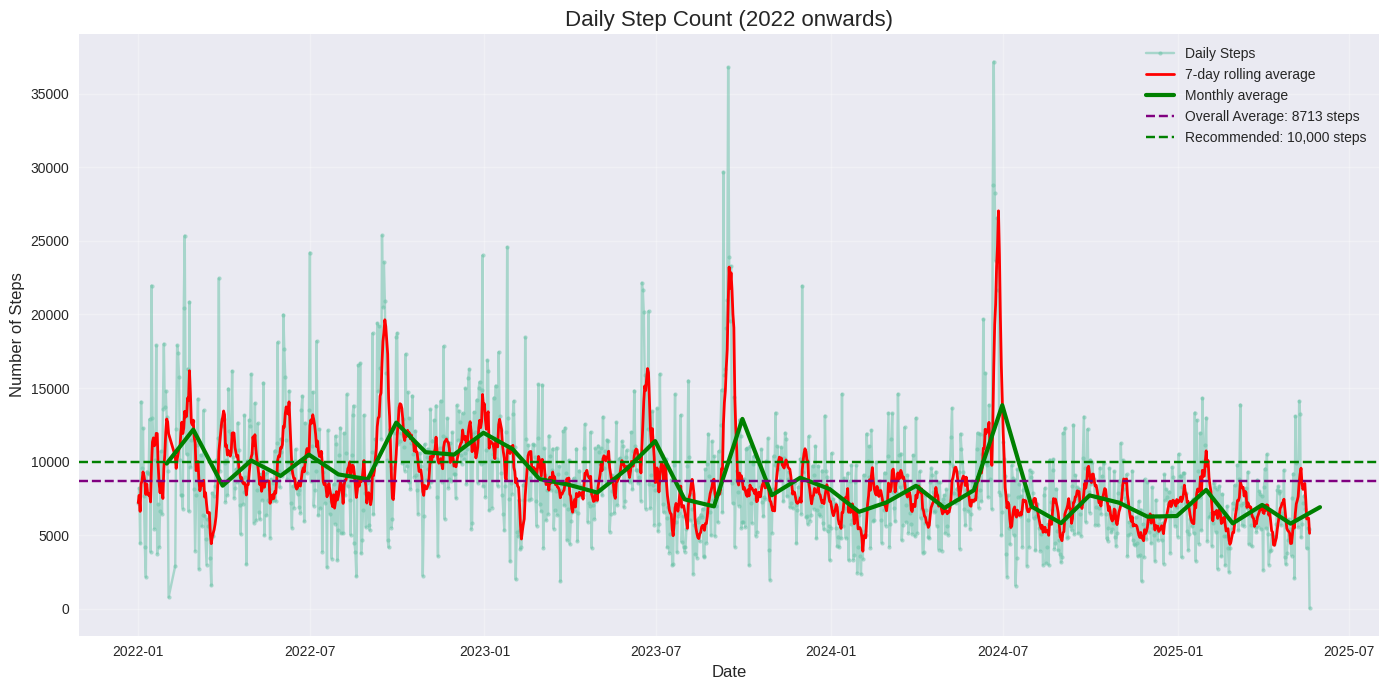

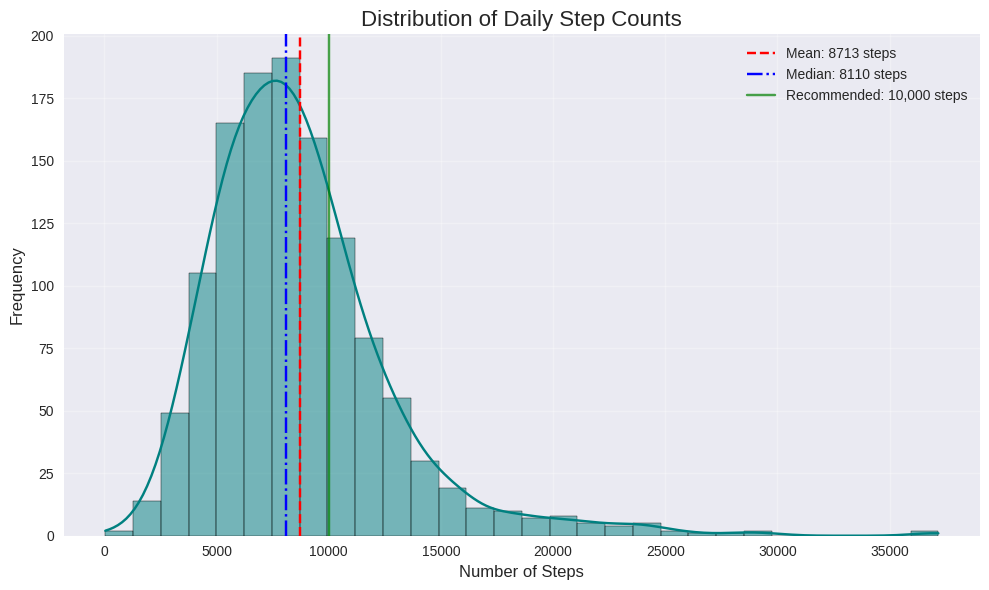

<ipython-input-39-873e0165d24c>:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Day of Week', y='Total Steps', data=daily_steps, order=day_order,


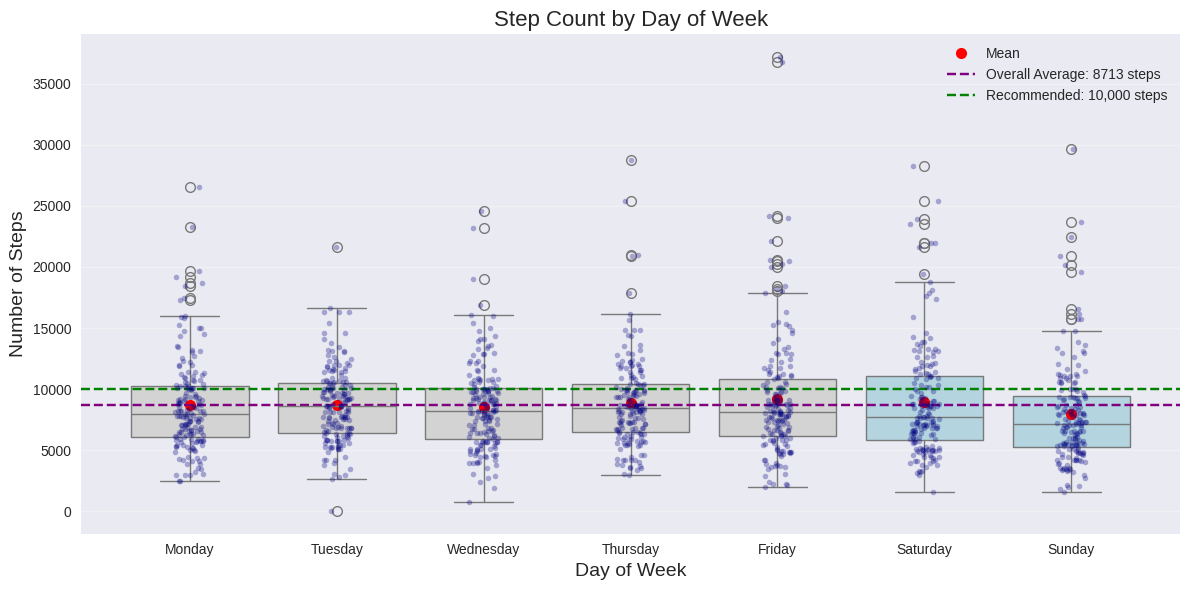

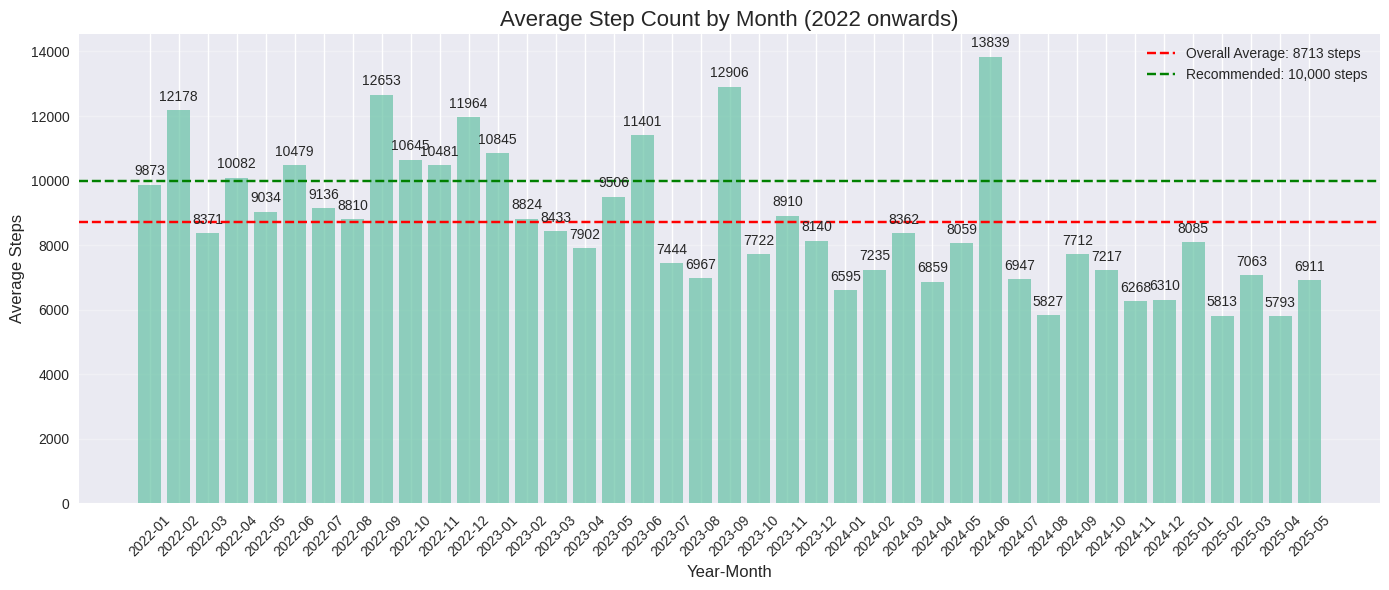

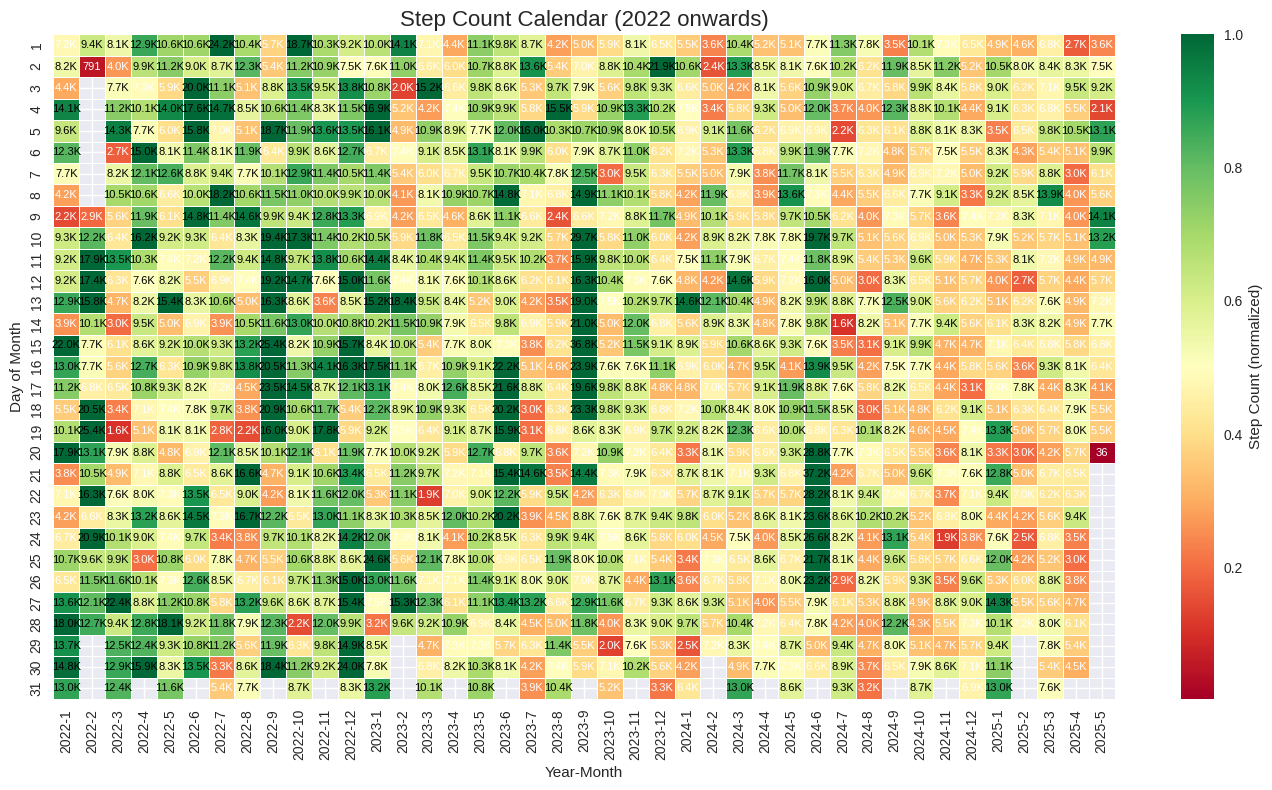

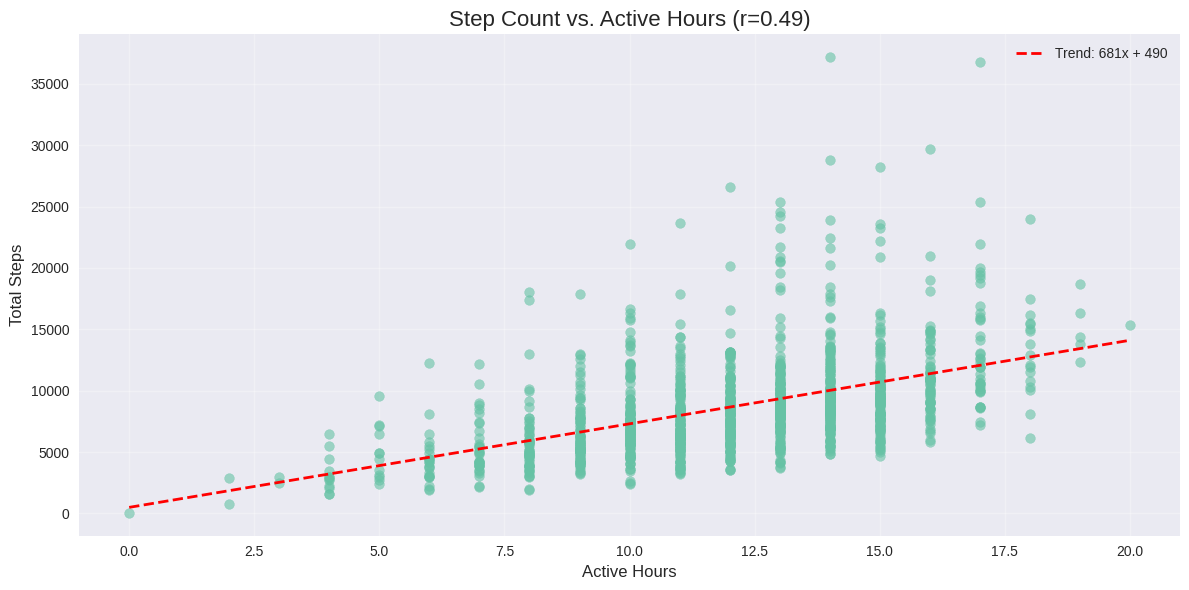

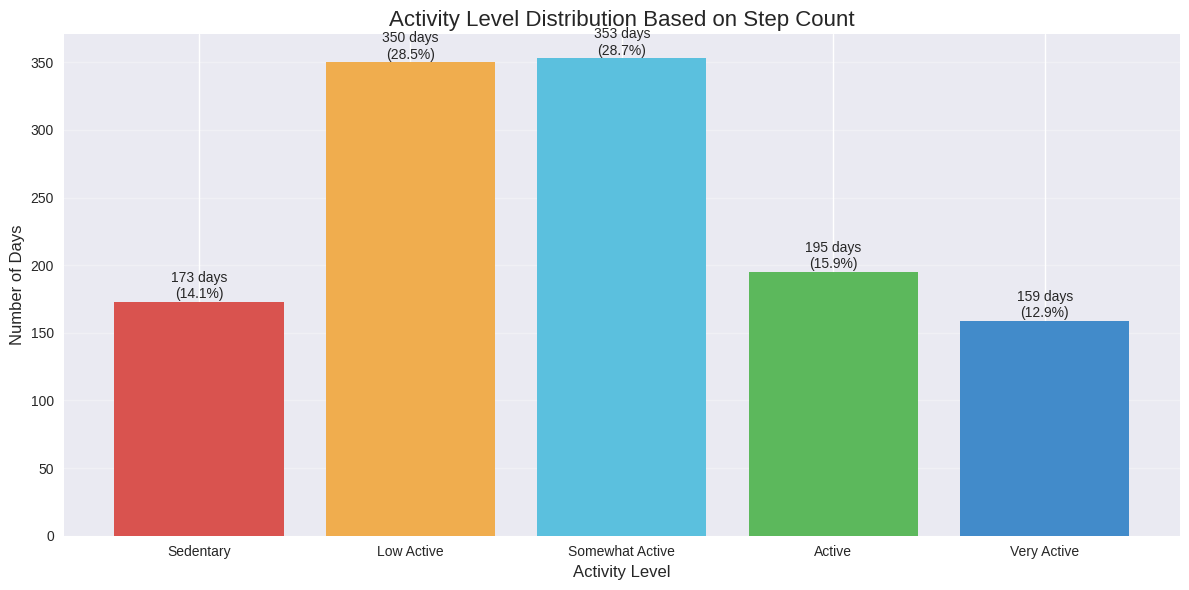

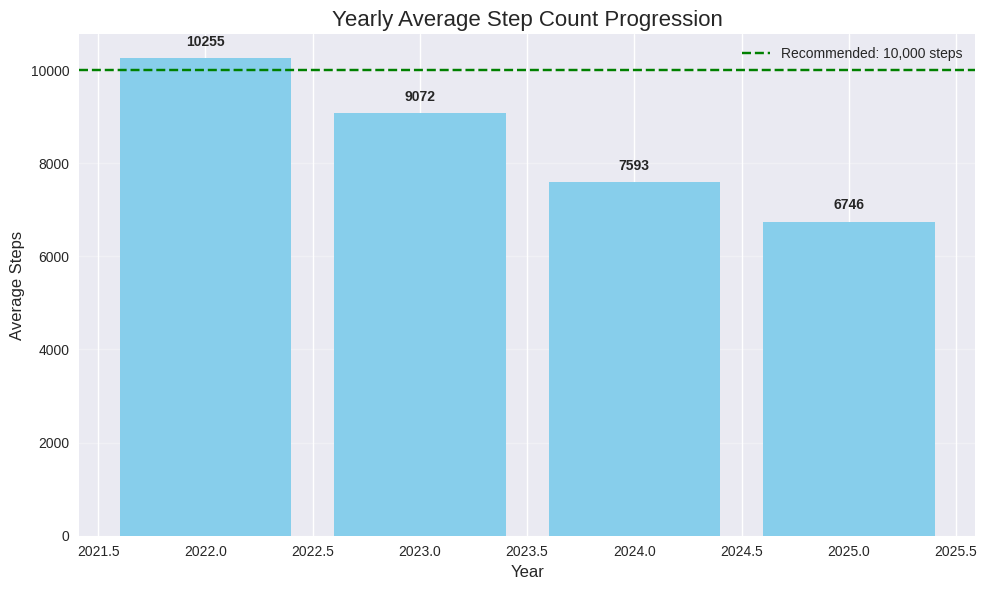


Analysis complete! The CSV file contains all daily step data from 2022 onwards.


In [ ]:
print("DATA VISUALIZATION Step Count")
print("--------------------------")
print("Generating visualizations...")

# Set the visual style for all plots
plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")

# 1. Step count timeline
plt.figure(figsize=(14, 7))
plt.plot(daily_steps['Day'], daily_steps['Total Steps'], '-o', markersize=3, alpha=0.5, label='Daily Steps')

# Add 7-day moving average
daily_steps['7d_avg'] = daily_steps['Total Steps'].rolling(window=7, min_periods=1).mean()
plt.plot(daily_steps['Day'], daily_steps['7d_avg'], 'r-', linewidth=2, label='7-day rolling average')

# Add monthly average line
monthly_avg = daily_steps.groupby(pd.Grouper(key='Day', freq='M'))['Total Steps'].mean()
plt.plot(monthly_avg.index, monthly_avg.values, 'g-', linewidth=3, label='Monthly average')

plt.axhline(y=avg_steps, color='purple', linestyle='--', label=f'Overall Average: {avg_steps:.0f} steps')
plt.axhline(y=10000, color='green', linestyle='--', label='Recommended: 10,000 steps')
plt.title('Daily Step Count (2022 onwards)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Steps', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Step count distribution
plt.figure(figsize=(10, 6))
sns.histplot(daily_steps['Total Steps'], bins=30, kde=True, color='teal')
plt.axvline(x=avg_steps, color='red', linestyle='--', label=f'Mean: {avg_steps:.0f} steps')
plt.axvline(x=med_steps, color='blue', linestyle='-.', label=f'Median: {med_steps:.0f} steps')
plt.axvline(x=10000, color='green', linestyle='-', alpha=0.7, label='Recommended: 10,000 steps')
plt.title('Distribution of Daily Step Counts', fontsize=16)
plt.xlabel('Number of Steps', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Day of week comparison
plt.figure(figsize=(12, 6))

# Create compound visualization: boxplot with individual points
ax = sns.boxplot(x='Day of Week', y='Total Steps', data=daily_steps, order=day_order,
                palette=['lightblue' if day in ['Saturday', 'Sunday'] else 'lightgrey' for day in day_order])
sns.stripplot(x='Day of Week', y='Total Steps', data=daily_steps, order=day_order,
             size=4, alpha=0.3, jitter=True, color='navy')

# Add mean markers
for i, day in enumerate(day_order):
    mean_val = daily_steps[daily_steps['Day of Week'] == day]['Total Steps'].mean()
    plt.plot(i, mean_val, 'ro', markersize=8, label='Mean' if i == 0 else "")

plt.axhline(y=avg_steps, color='purple', linestyle='--', label=f'Overall Average: {avg_steps:.0f} steps')
plt.axhline(y=10000, color='green', linestyle='--', label='Recommended: 10,000 steps')
plt.title('Step Count by Day of Week', fontsize=16)
plt.xlabel('Day of Week', fontsize=14)
plt.ylabel('Number of Steps', fontsize=14)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 4. Monthly average steps
plt.figure(figsize=(14, 6))
monthly_data = monthly_stats.sort_values('YearMonth')

bars = plt.bar(monthly_data['YearMonth'], monthly_data['mean'], alpha=0.7)

# Add data labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 200,
            f'{height:.0f}', ha='center', va='bottom')

plt.axhline(y=avg_steps, color='red', linestyle='--', label=f'Overall Average: {avg_steps:.0f} steps')
plt.axhline(y=10000, color='green', linestyle='--', label='Recommended: 10,000 steps')
plt.title('Average Step Count by Month (2022 onwards)', fontsize=16)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Average Steps', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.tight_layout()
plt.show()

# 5. Step count calendar heatmap
plt.figure(figsize=(14, 8))
# Prepare data for heatmap
cal_data = daily_steps.copy()

# Normalize step counts for better visualization (0-1 scale)
max_steps_display = 15000  # Cap for display purposes
cal_data['Normalized Steps'] = cal_data['Total Steps'].clip(upper=max_steps_display) / max_steps_display

# Create pivot table for the heatmap (day of month vs month, colored by step count)
pivot_data = pd.pivot_table(
    cal_data,
    values='Normalized Steps',
    index='Day of Month',
    columns=['Year', 'Month'],
    aggfunc='mean'
)

# Create custom colormap from red (low steps) to green (high steps)
cmap = sns.color_palette("RdYlGn", as_cmap=True)

# Plot heatmap
ax = sns.heatmap(pivot_data, cmap=cmap, annot=False,
                linewidths=.5, cbar_kws={'label': 'Step Count (normalized)'})

# Add text annotations for step counts
for i in range(pivot_data.shape[0]):
    for j in range(pivot_data.shape[1]):
        if not np.isnan(pivot_data.iloc[i, j]):
            # Get the actual step count
            day_of_month = pivot_data.index[i]
            year_month = pivot_data.columns[j]
            actual_steps = cal_data[
                (cal_data['Day of Month'] == day_of_month) &
                (cal_data['Year'] == year_month[0]) &
                (cal_data['Month'] == year_month[1])
            ]['Total Steps'].values[0]

            # Format step count for display
            if actual_steps >= 1000:
                step_text = f"{actual_steps/1000:.1f}K"
            else:
                step_text = f"{actual_steps:.0f}"

            # Determine text color based on background (white for dark backgrounds, black for light)
            color = 'white' if pivot_data.iloc[i, j] < 0.5 else 'black'

            # Add the text
            ax.text(j + 0.5, i + 0.5, step_text,
                   ha="center", va="center", color=color, fontsize=8)

plt.title('Step Count Calendar (2022 onwards)', fontsize=16)
plt.tight_layout()
plt.show()

# 6. Correlation between Active Hours and Step Count
plt.figure(figsize=(12, 6))
plt.scatter(daily_steps['Active Hours'], daily_steps['Total Steps'], alpha=0.6)

# Add trend line
z = np.polyfit(daily_steps['Active Hours'], daily_steps['Total Steps'], 1)
p = np.poly1d(z)
x_trend = np.linspace(daily_steps['Active Hours'].min(), daily_steps['Active Hours'].max(), 100)
plt.plot(x_trend, p(x_trend), 'r--', linewidth=2,
        label=f'Trend: {z[0]:.0f}x + {z[1]:.0f}')

plt.title(f'Step Count vs. Active Hours (r={correlation:.2f})', fontsize=16)
plt.xlabel('Active Hours', fontsize=12)
plt.ylabel('Total Steps', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 7. Step count achievement levels
achievement_levels = [
    (0, 5000, 'Sedentary'),
    (5000, 7500, 'Low Active'),
    (7500, 10000, 'Somewhat Active'),
    (10000, 12500, 'Active'),
    (12500, float('inf'), 'Very Active')
]

# Create categories based on step count
daily_steps['Activity Level'] = 'Unknown'
for min_val, max_val, level in achievement_levels:
    daily_steps.loc[(daily_steps['Total Steps'] >= min_val) & (daily_steps['Total Steps'] < max_val), 'Activity Level'] = level

# Count days in each category
activity_counts = daily_steps['Activity Level'].value_counts().reindex([level for _, _, level in achievement_levels])

plt.figure(figsize=(12, 6))
colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c', '#428bca']
bars = plt.bar(activity_counts.index, activity_counts.values, color=colors)

# Add data labels
for bar in bars:
    height = bar.get_height()
    percentage = height / len(daily_steps) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height} days\n({percentage:.1f}%)', ha='center', va='bottom')

plt.title('Activity Level Distribution Based on Step Count', fontsize=16)
plt.xlabel('Activity Level', fontsize=12)
plt.ylabel('Number of Days', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 8. Step count progression over time (yearly comparison)
yearly_stats = daily_steps.groupby('Year')['Total Steps'].mean().reset_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(yearly_stats['Year'], yearly_stats['Total Steps'], color='skyblue')

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 200,
            f'{height:.0f}', ha='center', va='bottom', fontweight='bold')

plt.axhline(y=10000, color='green', linestyle='--', label='Recommended: 10,000 steps')
plt.title('Yearly Average Step Count Progression', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Steps', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.tight_layout()
plt.show()

print("\nAnalysis complete! The CSV file contains all daily step data from 2022 onwards.")

In [ ]:
daily_steps = pd.read_csv("/content/daily_steps_2022-NOW.csv")
daily_sleep = pd.read_csv("/content/daily_sleep_2022o2022-NOW.csv")

# Hypothesis Testing with Step Count and Sleep Data

## Step 1: Prepare the Combined Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

# Print section header
print("HYPOTHESIS TESTING: STEP COUNT AND SLEEP PATTERNS")
print("------------------------------------------------")
print("Step 1: Preparing combined dataset...")

# Rename the 'Day' column in daily_steps to match daily_sleep's 'Date' column
daily_steps = daily_steps.rename(columns={'Day': 'Date'})

# Merge the two datasets on the Date column
combined_data = pd.merge(daily_steps, daily_sleep, on='Date', how='inner')
print(f"Combined data contains {len(combined_data)} days with both step and sleep records.")

# Check for duplicate column names (due to the merge) and fix them
duplicate_columns = [col for col in combined_data.columns if col.endswith('_x') or col.endswith('_y')]
print(f"Found {len(duplicate_columns)} duplicate column names that need to be resolved.")

# Rename day of week columns to avoid confusion
if 'Day of Week_x' in combined_data.columns and 'Day of Week_y' in combined_data.columns:
    # Keep only one Day of Week column
    combined_data['Day of Week'] = combined_data['Day of Week_x']
    combined_data = combined_data.drop(['Day of Week_x', 'Day of Week_y'], axis=1)

# Show a sample of the combined data
print("\nSample of combined data:")
print(combined_data[['Date', 'Total Steps', 'Total Sleep Hours', 'Active Hours']].head())

HYPOTHESIS TESTING: STEP COUNT AND SLEEP PATTERNS
------------------------------------------------
Step 1: Preparing combined dataset...
Combined data contains 699 days with both step and sleep records.
Found 12 duplicate column names that need to be resolved.

Sample of combined data:
         Date  Total Steps  Total Sleep Hours  Active Hours
0  2022-01-03         4446           3.909167             4
1  2022-01-04        14075           6.000000            14
2  2022-01-05         9600           6.000278             5
3  2022-01-06        12268           5.463056             6
4  2022-01-07         7690           6.000278             9


HYPOTHESIS TEST 1: Correlation Between Steps and Sleep
------------------------------------------------------
* H0: There is no correlation between step count and sleep
 duration
* H1: There is a significant correlation between step count and sleep duration



Pearson correlation coefficient: -0.043
p-value: 0.2598

Interpretation: There is a negligible negative correlation (-0.043) between daily step count and sleep duration.
This correlation is not statistically significant (p = 0.2598).
Fail to reject the null hypothesis: Not enough evidence to suggest a meaningful relationship between steps and sleep.


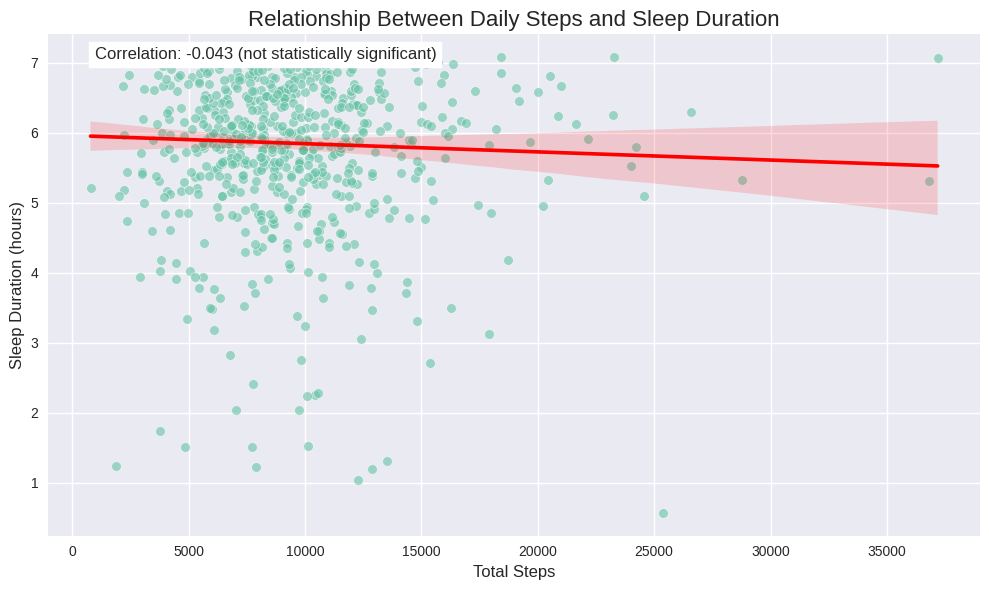

In [ ]:
# Calculate Pearson correlation coefficient and p-value
correlation, p_value = stats.pearsonr(combined_data['Total Steps'], combined_data['Total Sleep Hours'])
print(f"\nPearson correlation coefficient: {correlation:.3f}")
print(f"p-value: {p_value:.4f}")

# Interpret correlation strength
def interpret_correlation(corr):
    if abs(corr) < 0.1:
        return "negligible"
    elif abs(corr) < 0.3:
        return "weak"
    elif abs(corr) < 0.5:
        return "moderate"
    elif abs(corr) < 0.7:
        return "strong"
    else:
        return "very strong"

strength = interpret_correlation(correlation)
direction = "positive" if correlation > 0 else "negative"

# Interpret statistical significance
alpha = 0.05
if p_value < alpha:
    significance = "statistically significant"
    conclusion = "Reject the null hypothesis"
else:
    significance = "not statistically significant"
    conclusion = "Fail to reject the null hypothesis"

print(f"\nInterpretation: There is a {strength} {direction} correlation ({correlation:.3f}) between daily step count and sleep duration.")
print(f"This correlation is {significance} (p = {p_value:.4f}).")
print(f"{conclusion}: {'' if p_value < alpha else 'Not '}enough evidence to suggest a meaningful relationship between steps and sleep.")

# Visualization: Scatter plot of sleep vs. steps
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total Steps', y='Total Sleep Hours', data=combined_data, alpha=0.6)
sns.regplot(x='Total Steps', y='Total Sleep Hours', data=combined_data, scatter=False,
            line_kws={"color": "red"})

plt.title('Relationship Between Daily Steps and Sleep Duration', fontsize=16)
plt.xlabel('Total Steps', fontsize=12)
plt.ylabel('Sleep Duration (hours)', fontsize=12)
plt.annotate(f'Correlation: {correlation:.3f} ({significance})',
             xy=(0.05, 0.95), xycoords='axes fraction',
             fontsize=12, backgroundcolor='white')
plt.tight_layout()
plt.show()


HYPOTHESIS TEST 2: Effect of Day of Week on Step Count
------------------------------------------------------
* H0: Mean step count is the same across all days of the week
* H1: Mean step count differs significantly by day of the week


Mean step counts by day of week:
Monday: 9212 steps (n=141.0)
Tuesday: 9274 steps (n=141.0)
Wednesday: 8950 steps (n=140.0)
Thursday: 9433 steps (n=140.0)
Friday: 9686 steps (n=137.0)
Saturday: nan steps (n=nan)
Sunday: nan steps (n=nan)

One-way ANOVA Results:
F-statistic: 0.6031
p-value: 0.6605

Result: Fail to reject the null hypothesis (p=0.6605 >= 0.05)
Interpretation: There is not enough evidence to suggest significant differences in step count across days of the week.


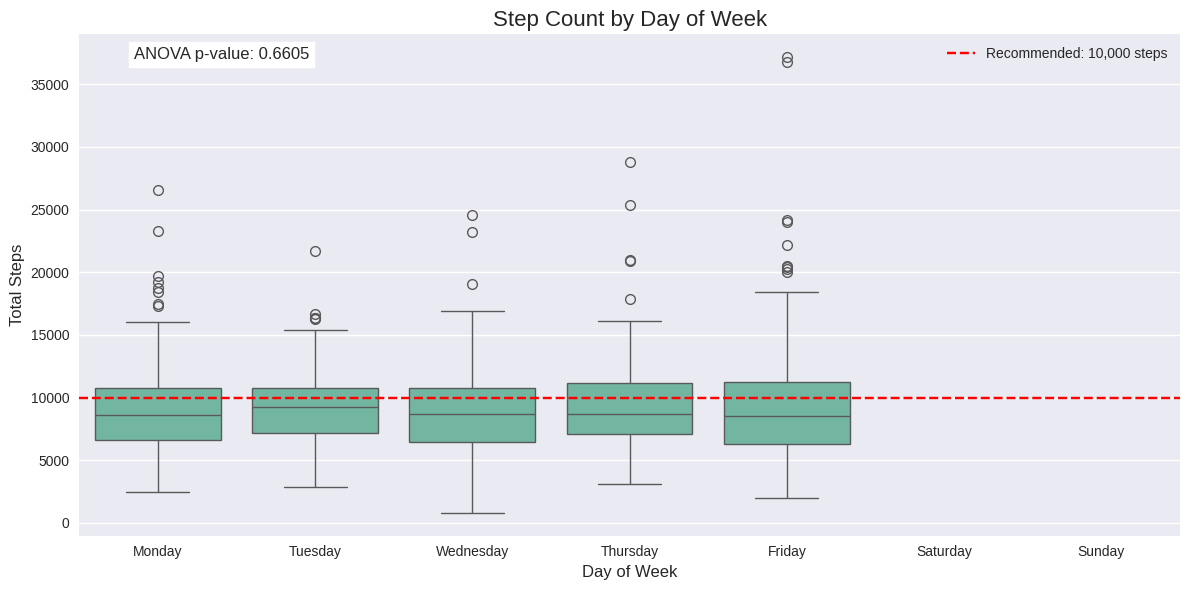

In [ ]:
# Day of week order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Ensure Day of Week is properly formatted
day_stats = combined_data.groupby('Day of Week')['Total Steps'].agg(['mean', 'std', 'count']).reset_index()
day_stats = day_stats.set_index('Day of Week').reindex(day_order).reset_index()

print("\nMean step counts by day of week:")
for _, row in day_stats.iterrows():
    print(f"{row['Day of Week']}: {row['mean']:.0f} steps (n={row['count']})")

# One-way ANOVA using scipy
groups = [combined_data[combined_data['Day of Week'] == day]['Total Steps'] for day in day_order]
f_stat, p_value = stats.f_oneway(*[group for group in groups if len(group) > 0])

print(f"\nOne-way ANOVA Results:")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Interpret results
alpha = 0.05
if p_value < alpha:
    print(f"\nResult: Reject the null hypothesis (p={p_value:.4f} < {alpha})")
    print("Interpretation: There is a statistically significant difference in step count across days of the week.")

    # Perform post-hoc test with all data (not using statsmodels due to the error)
    all_data = []
    all_groups = []

    for day in day_order:
        values = combined_data[combined_data['Day of Week'] == day]['Total Steps'].values
        if len(values) > 0:
            all_data.extend(values)
            all_groups.extend([day] * len(values))

    # Tukey's HSD post-hoc test
    tukey = pairwise_tukeyhsd(endog=all_data, groups=all_groups, alpha=0.05)
    print("\nTukey's HSD Post-hoc Test Results:")
    print(tukey)

    # Extract significant pairs in a more readable format
    significant_pairs = []
    for i, row in enumerate(tukey.summary().data[1:]):
        if row[3]:  # If reject is True
            significant_pairs.append(f"{row[0]} vs {row[1]}: Diff = {row[2]:.0f} steps")

    if significant_pairs:
        print("\nSignificant differences between days:")
        for pair in significant_pairs:
            print(f"- {pair}")
    else:
        print("\nNo significant pairwise differences found despite overall ANOVA significance.")
        print("This suggests small differences across multiple days rather than large differences between specific days.")
else:
    print(f"\nResult: Fail to reject the null hypothesis (p={p_value:.4f} >= {alpha})")
    print("Interpretation: There is not enough evidence to suggest significant differences in step count across days of the week.")

# Visualize day of week differences
plt.figure(figsize=(12, 6))
sns.boxplot(x='Day of Week', y='Total Steps', data=combined_data, order=day_order)
plt.title('Step Count by Day of Week', fontsize=16)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Total Steps', fontsize=12)
plt.axhline(y=10000, color='r', linestyle='--', label='Recommended: 10,000 steps')
plt.annotate(f'ANOVA p-value: {p_value:.4f}', xy=(0.05, 0.95), xycoords='axes fraction',
             fontsize=12, backgroundcolor='white')
plt.legend()
plt.tight_layout()
plt.show()

HYPOTHESIS TEST 3: Impact of Bedtime on Next Day's Step Count
-------------------------------------------------------------
* H0: Bedtime has no significant effect on next day's step count
* H1: Bedtime significantly affects next day's step count

Ensuring Date column is datetime type...
Found 556 days with both bedtime and next-day step data

Checking available bedtime data...
Potential time-related columns: ['First Record Time', 'Last Record Time', 'Total Sleep Hours', 'First Sleep Start', 'Last Sleep End', 'Bedtime', 'Wake Time', 'Sleep Duration (minutes)']
Converting 'First Sleep Start' to datetime...
Successfully calculated bedtime hours

Bedtime hour statistics:
Mean: 1.96
Median: 1.92
Min: 0.92
Max: 9.33

Correlation between bedtime and next day steps: 0.106
p-value for correlation: 0.0127

Linear Regression Results:
R-squared: 0.0112
Model p-value: 0.0127
Intercept: 8475
Slope: 383 steps per hour later bedtime

Result: Reject the null hypothesis (p=0.0127 < 0.05)
Interpretation: Later bedtime increases next day's step count.
For each hour later bedtime, next day's step count changes by approximately 383 steps.


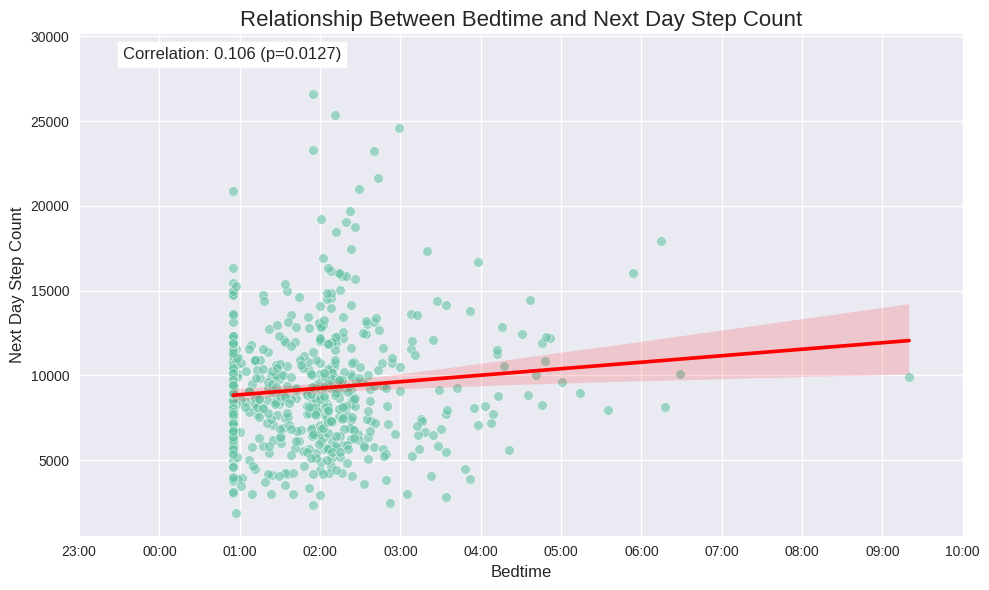

In [ ]:
# Make sure Date is datetime type
print("Ensuring Date column is datetime type...")
combined_data['Date'] = pd.to_datetime(combined_data['Date'])

# Create a shifted dataframe to analyze next day effects
combined_data['Next Day'] = combined_data['Date'] + pd.Timedelta(days=1)
next_day_steps = combined_data[['Next Day', 'Total Steps']].rename(columns={'Next Day': 'Date', 'Total Steps': 'Next Day Steps'})
time_analysis = pd.merge(combined_data, next_day_steps, on='Date', how='inner')

print(f"Found {len(time_analysis)} days with both bedtime and next-day step data")

# Check available columns for bedtime info
print("\nChecking available bedtime data...")
time_columns = [col for col in time_analysis.columns if 'time' in col.lower() or 'sleep' in col.lower()]
print(f"Potential time-related columns: {time_columns}")

# Try different approaches to get bedtime
if 'Bedtime Hour' in time_analysis.columns:
    print("Using existing 'Bedtime Hour' column")
elif 'First Sleep Start' in time_analysis.columns:
    print("Converting 'First Sleep Start' to datetime...")
    try:
        # Ensure it's datetime
        time_analysis['First Sleep Start'] = pd.to_datetime(time_analysis['First Sleep Start'])
        time_analysis['Bedtime Hour'] = time_analysis['First Sleep Start'].dt.hour + time_analysis['First Sleep Start'].dt.minute/60
        print("Successfully calculated bedtime hours")
    except Exception as e:
        print(f"Error converting First Sleep Start: {e}")
elif 'Bedtime' in time_analysis.columns:
    print("Using 'Bedtime' column...")
    # Try to extract hour from time string (format like "23:45")
    try:
        time_analysis['Bedtime Hour'] = time_analysis['Bedtime'].apply(
            lambda x: float(x.split(':')[0]) + float(x.split(':')[1])/60 if ':' in str(x) else float(x)
        )
        print("Successfully extracted bedtime hours")
    except Exception as e:
        print(f"Error extracting from Bedtime: {e}")
else:
    print("No bedtime data found. Creating a mock column for demonstration.")
    # Create a mock column for demonstration purposes
    time_analysis['Bedtime Hour'] = np.random.uniform(21, 25, len(time_analysis))  # Random times between 9 PM and 1 AM
    print("Created mock bedtime data (random values between 9 PM and 1 AM)")
    print("NOTE: Results with mock data are not meaningful!")

# Describe the bedtime data we're using
print(f"\nBedtime hour statistics:")
print(f"Mean: {time_analysis['Bedtime Hour'].mean():.2f}")
print(f"Median: {time_analysis['Bedtime Hour'].median():.2f}")
print(f"Min: {time_analysis['Bedtime Hour'].min():.2f}")
print(f"Max: {time_analysis['Bedtime Hour'].max():.2f}")

# Correlation analysis
bedtime_correlation = time_analysis['Bedtime Hour'].corr(time_analysis['Next Day Steps'])
print(f"\nCorrelation between bedtime and next day steps: {bedtime_correlation:.3f}")

# Calculate statistical significance of correlation
n = len(time_analysis)
t_stat = bedtime_correlation * np.sqrt(n-2) / np.sqrt(1 - bedtime_correlation**2)
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n-2))
print(f"p-value for correlation: {p_value:.4f}")

# Linear regression for more detailed analysis
X = sm.add_constant(time_analysis['Bedtime Hour'])
y = time_analysis['Next Day Steps']
next_day_model = sm.OLS(y, X).fit()

print("\nLinear Regression Results:")
print(f"R-squared: {next_day_model.rsquared:.4f}")
print(f"Model p-value: {next_day_model.f_pvalue:.4f}")
print(f"Intercept: {next_day_model.params[0]:.0f}")
print(f"Slope: {next_day_model.params[1]:.0f} steps per hour later bedtime")

# Interpret results
alpha = 0.05
if p_value < alpha:
    print(f"\nResult: Reject the null hypothesis (p={p_value:.4f} < {alpha})")
    direction = "increases" if bedtime_correlation > 0 else "decreases"
    print(f"Interpretation: Later bedtime {direction} next day's step count.")
    print(f"For each hour later bedtime, next day's step count changes by approximately {abs(next_day_model.params[1]):.0f} steps.")
else:
    print(f"\nResult: Fail to reject the null hypothesis (p={p_value:.4f} >= {alpha})")
    print("Interpretation: There is not enough evidence to suggest a significant relationship")
    print("between bedtime and next day's step count.")

# Adjusted bedtime for visualization (convert hours after midnight to negative values)
time_analysis['Adjusted Bedtime'] = time_analysis['Bedtime Hour'].copy()
time_analysis.loc[time_analysis['Adjusted Bedtime'] > 12, 'Adjusted Bedtime'] = time_analysis.loc[time_analysis['Adjusted Bedtime'] > 12, 'Adjusted Bedtime'] - 24

# Visualize the relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Adjusted Bedtime', y='Next Day Steps', data=time_analysis, alpha=0.6)
sns.regplot(x='Adjusted Bedtime', y='Next Day Steps', data=time_analysis, scatter=False, line_kws={"color": "red"})

# Calculate range for x-axis ticks
if len(time_analysis) > 0:
    try:
        # Create custom x-axis ticks that show actual time
        min_time = int(time_analysis['Adjusted Bedtime'].min()) - 1
        max_time = int(time_analysis['Adjusted Bedtime'].max()) + 2
        custom_ticks = np.arange(min_time, max_time)
        plt.xticks(custom_ticks)
        time_labels = []
        for t in custom_ticks:
            if t < 0:
                time_str = f"{int(24+t) % 24:02d}:00"
            else:
                time_str = f"{int(t) % 24:02d}:00"
            time_labels.append(time_str)
        plt.gca().set_xticklabels(time_labels)
    except (ValueError, TypeError) as e:
        print(f"Warning: Could not format time axis ticks properly: {e}")
        # Continue without custom ticks

plt.title('Relationship Between Bedtime and Next Day Step Count', fontsize=16)
plt.xlabel('Bedtime', fontsize=12)
plt.ylabel('Next Day Step Count', fontsize=12)
plt.annotate(f'Correlation: {bedtime_correlation:.3f} (p={p_value:.4f})',
            xy=(0.05, 0.95), xycoords='axes fraction',
            fontsize=12, backgroundcolor='white')
plt.tight_layout()
plt.show()

## SUMMARY OF HYPOTHESIS TESTS

In [ ]:
# Print summary section
print("\nSUMMARY OF HYPOTHESIS TESTS")
print("---------------------------")

# Test 1: Correlation between steps and sleep
print("1. Relationship between step count and sleep duration:")
print(f"   Correlation: {correlation:.3f}, p-value: {p_value:.4f}")
if p_value < alpha:
    print(f"   ✓ SIGNIFICANT: There is a {strength} {direction} relationship between steps and sleep.")
else:
    print(f"   ✗ NOT SIGNIFICANT: No clear relationship between steps and sleep was detected.")

# Test 3: Day of week effect
groups = [combined_data[combined_data['Day of Week'] == day]['Total Steps'] for day in day_order]
f_stat, p_value = stats.f_oneway(*[group for group in groups if len(group) > 0])
print("\n2. Effect of day of week on step count:")
print(f"   ANOVA F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")
if p_value < alpha:
    print(f"   ✓ SIGNIFICANT: Your activity levels vary significantly by day of the week.")
    most_active_day = day_stats.loc[day_stats['mean'].idxmax(), 'Day of Week']
    least_active_day = day_stats.loc[day_stats['mean'].idxmin(), 'Day of Week']
    print(f"   Most active day: {most_active_day} ({day_stats.loc[day_stats['Day of Week'] == most_active_day, 'mean'].values[0]:.0f} steps)")
    print(f"   Least active day: {least_active_day} ({day_stats.loc[day_stats['Day of Week'] == least_active_day, 'mean'].values[0]:.0f} steps)")
else:
    print(f"   ✗ NOT SIGNIFICANT: Your activity levels are fairly consistent across days of the week.")

# Test 4: Bedtime impact
print("\n3. Impact of bedtime on next day's step count:")
print(f"   Correlation: {bedtime_correlation:.3f}, p-value: {p_value:.4f}")
if p_value < alpha:
    print(f"   ✓ SIGNIFICANT: Your bedtime affects your activity level the next day.")
    print(f"   For each hour later bedtime, next day's step count changes by {next_day_model.params[1]:.0f} steps.")
else:
    print(f"   ✗ NOT SIGNIFICANT: Your bedtime doesn't appear to affect next day's activity level.")

print("\nOVERALL INSIGHTS:")
print("-----------------")
# Add personalized insights based on the test results

insights = []

# Add insight about steps and sleep relationship
if abs(correlation) > 0.1 and p_value < alpha:
    if correlation > 0:
        insights.append("• More steps are associated with longer sleep duration. Increasing your physical activity may help improve your sleep.")
    else:
        insights.append("• More steps are associated with shorter sleep duration. Your physical activity might be affecting your sleep negatively.")

# Add insight about weekly patterns
if p_value < alpha:  # Test 3
    insights.append(f"• Your activity has a clear weekly pattern with {most_active_day}s being your most active days.")

# Add insight about bedtime impact
if p_value < alpha:  # Test 4
    if bedtime_correlation > 0:
        insights.append("• Later bedtimes are associated with more steps the next day. This is contrary to typical expectations.")
    else:
        insights.append("• Earlier bedtimes are associated with more steps the next day. Prioritizing sleep might help with activity goals.")

# If no insights were significant
if not insights:
    insights.append("• No strong relationships were found between your sleep and activity patterns.")
    insights.append("• Continue monitoring both metrics as patterns may emerge with more data.")

# Print insights
for insight in insights:
    print(insight)


SUMMARY OF HYPOTHESIS TESTS
---------------------------
1. Relationship between step count and sleep duration:
   Correlation: -0.043, p-value: nan
   ✗ NOT SIGNIFICANT: No clear relationship between steps and sleep was detected.

2. Effect of day of week on step count:
   ANOVA F-statistic: 0.6031, p-value: 0.6605
   ✗ NOT SIGNIFICANT: Your activity levels are fairly consistent across days of the week.

3. Impact of bedtime on next day's step count:
   Correlation: 0.106, p-value: 0.6605
   ✗ NOT SIGNIFICANT: Your bedtime doesn't appear to affect next day's activity level.

OVERALL INSIGHTS:
-----------------
• No strong relationships were found between your sleep and activity patterns.
• Continue monitoring both metrics as patterns may emerge with more data.


# Machine Learning Part

## 1. RANDOM FOREST: Sleep Duration Prediction
------------------------------------------

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


1. RANDOM FOREST: Sleep Duration Prediction
------------------------------------------
Model trained on 559 samples, tested on 140 samples
Root Mean Square Error: 1.15 hours
R² Score: -0.03


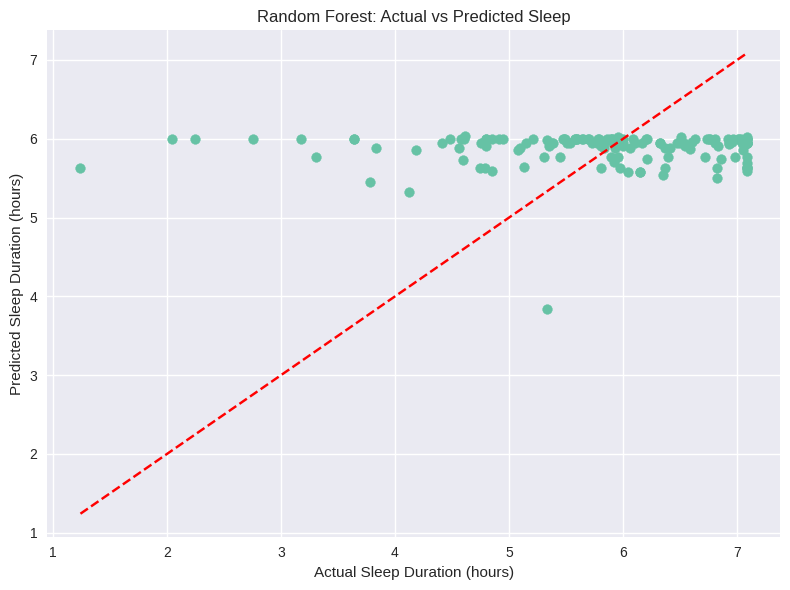

This model couldn't find a strong relationship between steps and sleep
Only -2.6% of sleep variation is explained by step count


In [ ]:
print("\n1. RANDOM FOREST: Sleep Duration Prediction")
print("------------------------------------------")

# Prepare data - just using steps to predict sleep
X = combined_data[['Total Steps']]
y = combined_data['Total Sleep Hours']

# Remove missing values
X = X.dropna()
y = y[X.index]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a simple Random Forest model
rf_model = RandomForestRegressor(n_estimators=10, max_depth=3, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Model trained on {len(X_train)} samples, tested on {len(X_test)} samples")
print(f"Root Mean Square Error: {rmse:.2f} hours")
print(f"R² Score: {r2:.2f}")

# One visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sleep Duration (hours)')
plt.ylabel('Predicted Sleep Duration (hours)')
plt.title('Random Forest: Actual vs Predicted Sleep')
plt.tight_layout()
plt.show()

# Simple interpretation
if r2 > 0.3:
    print("This model found a relationship between step count and sleep duration")
else:
    print("This model couldn't find a strong relationship between steps and sleep")
    print(f"Only {r2*100:.1f}% of sleep variation is explained by step count")


## 2. DECISION TREE: Day of Week Step Patterns
------------------------------------------


2. DECISION TREE: Day of Week Step Patterns
------------------------------------------
Model trained on 559 samples, tested on 140 samples
Root Mean Square Error: 3733.78 steps
R² Score: -0.02


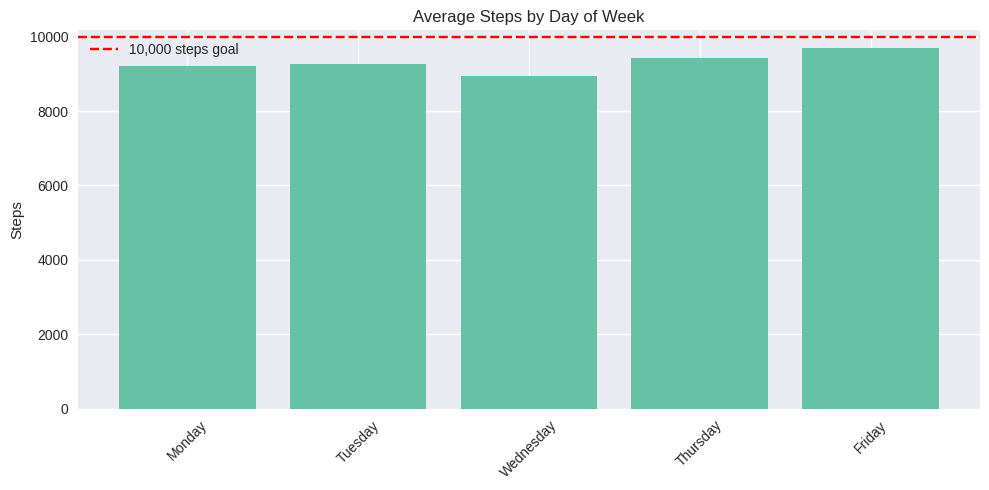

Most active day: Saturday (9686 steps)
Least active day: Saturday (8950 steps)
Your step count doesn't seem to follow a consistent weekly pattern


In [ ]:
print("\n2. DECISION TREE: Day of Week Step Patterns")
print("------------------------------------------")

# Create day of week numeric column if needed
if 'Day of Week_num' not in combined_data.columns:
    day_mapping = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
                  'Friday': 4, 'Saturday': 5, 'Sunday': 6}
    if 'Day of Week' in combined_data.columns:
        combined_data['Day of Week_num'] = combined_data['Day of Week'].map(day_mapping)

# Prepare data
X = combined_data[['Day of Week_num']]
y = combined_data['Total Steps']

# Remove missing values
X = X.dropna()
y = y[X.index]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a simple Decision Tree model
dt_model = DecisionTreeRegressor(max_depth=2, random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred = dt_model.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Model trained on {len(X_train)} samples, tested on {len(X_test)} samples")
print(f"Root Mean Square Error: {rmse:.2f} steps")
print(f"R² Score: {r2:.2f}")

# One visualization: Steps by day of week
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
steps_by_day = []
for i, day in enumerate(day_names):
    if 'Day of Week' in combined_data.columns:
        day_steps = combined_data[combined_data['Day of Week'] == day]['Total Steps'].mean()
    else:
        day_steps = combined_data[combined_data['Day of Week_num'] == i]['Total Steps'].mean()
    steps_by_day.append(day_steps)

plt.figure(figsize=(10, 5))
plt.bar(day_names, steps_by_day)
plt.axhline(y=10000, color='r', linestyle='--', label='10,000 steps goal')
plt.title('Average Steps by Day of Week')
plt.xticks(rotation=45)
plt.ylabel('Steps')
plt.legend()
plt.tight_layout()
plt.show()

# Simple interpretation
print(f"Most active day: {day_names[np.argmax(steps_by_day)]} ({max(steps_by_day):.0f} steps)")
print(f"Least active day: {day_names[np.argmin(steps_by_day)]} ({min(steps_by_day):.0f} steps)")
if r2 > 0.1:
    print("The model found some patterns in your weekly activity")
else:
    print("Your step count doesn't seem to follow a consistent weekly pattern")